### Download the dataset

In [35]:
!pip -q install kaggle
!pip -q install "fastprogress==1.0.3"

In [36]:
!export KAGGLE_API_TOKEN= ### here put ur kaggle api token

'export' is not recognized as an internal or external command,
operable program or batch file.


In [37]:
%%bash
mkdir -p /root/.config/kaggle/
cat <<EOF > /root/.config/kaggle/kaggle.json
{
  "username": "kaggel username",
  "key": "kaggle api token"
}
EOF

chmod 600 /root/.config/kaggle/kaggle.json

Couldn't find program: 'bash'


In [38]:
!kaggle datasets list | head

'head' is not recognized as an internal or external command,
operable program or batch file.


In [39]:
!kaggle datasets download -d benpepperpots/rust-iron-dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/benpepperpots/rust-iron-dataset
License(s): unknown




  0%|          | 0.00/729M [00:00<?, ?B/s]
  0%|          | 2.00M/729M [00:00<00:42, 18.0MB/s]
  1%|          | 9.00M/729M [00:00<00:17, 42.2MB/s]
  2%|▏         | 15.0M/729M [00:00<00:16, 46.7MB/s]
  3%|▎         | 21.0M/729M [00:00<00:15, 48.9MB/s]
  4%|▎         | 27.0M/729M [00:00<00:14, 51.9MB/s]
  4%|▍         | 32.0M/729M [00:00<00:14, 49.6MB/s]
  6%|▌         | 41.0M/729M [00:00<00:12, 58.5MB/s]
  6%|▋         | 47.0M/729M [00:00<00:13, 53.8MB/s]
  8%|▊         | 57.0M/729M [00:01<00:11, 62.7MB/s]
  9%|▉         | 64.0M/729M [00:01<00:10, 64.6MB/s]
 10%|█         | 73.0M/729M [00:01<00:11, 59.2MB/s]
 12%|█▏        | 84.0M/729M [00:01<00:09, 72.5MB/s]
 13%|█▎        | 92.0M/729M [00:01<00:09, 70.3MB/s]
 14%|█▎        | 100M/729M [00:01<00:11, 59.8MB/s] 
 15%|█▌        | 111M/729M [00:01<00:09, 70.8MB/s]
 16%|█▋        | 119M/729M [00:02<00:09, 69.7MB/s]
 18%|█▊        | 130M/729M [00:02<00:07, 80.0MB/s]
 19%|█▉        | 139M/729M [00:02<00:08, 73.5MB/s]
 21%|██        | 151M/72

### imports

In [40]:
import os
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler

import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

from torchvision.models import resnet18, ResNet18_Weights
from tqdm import tqdm

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

plt.ion()

### device setup

In [41]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps") # mac
else:
    device = torch.device("cpu")

print("Using device:", device)
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no gpu")

Using device: cuda
NVIDIA GeForce RTX 3070


### load data

In [42]:
from pathlib import Path

train_dir = Path("train/train")
val_dir   = Path("test/test")


In [43]:
# Data augmentation and normalization for training
# Just normalization for validation
train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    ),
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    ),
])

In [44]:
# create datasets
train_ds = ImageFolder(train_dir, transform=train_tfms)
val_ds   = ImageFolder(val_dir, transform=val_tfms)

print("Classes:", train_ds.classes)
print("Train size:", len(train_ds))
print("Val size:", len(val_ds))

Classes: ['CORROSION', 'NOCORROSION']
Train size: 1273
Val size: 182


In [45]:
# data loaders
batch_size = 32

num_workers = 0 if device.type == "mps" else 2
pin_memory = True if device.type == "cuda" else False

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 40
Val batches: 6


### sample images visualization

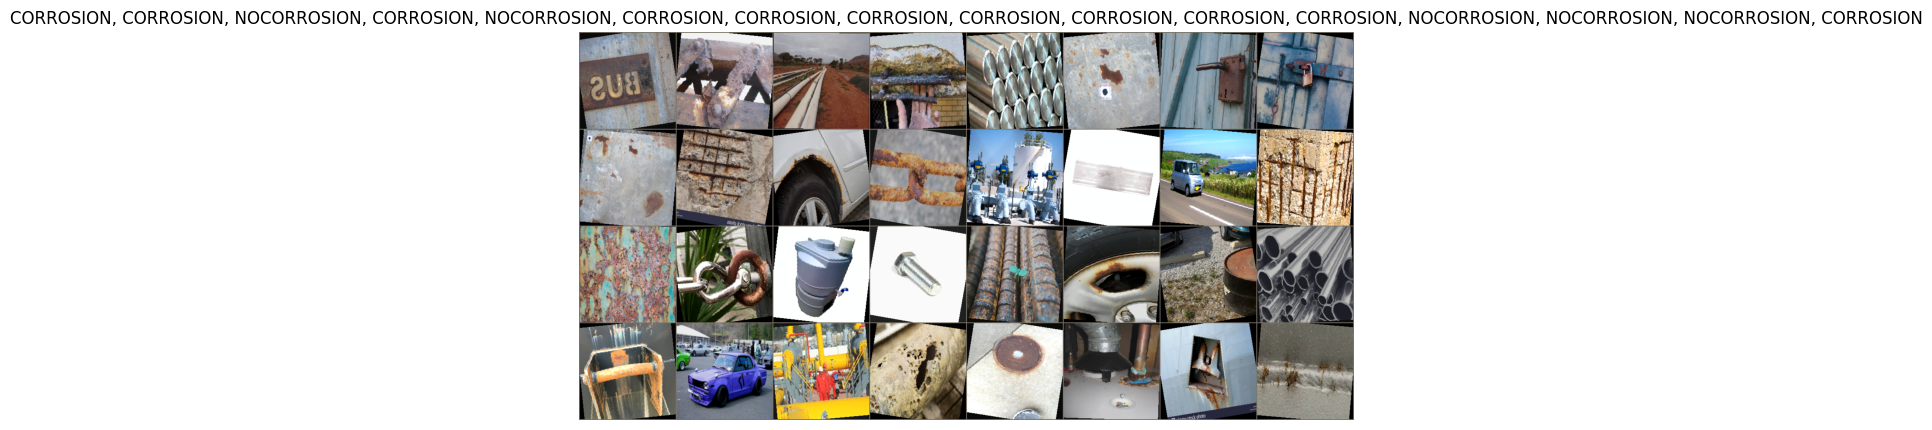

In [46]:
# visualize a few
def imshow(inp, title=None):
    """Display image for Tensor (expects CHW or grid tensor)."""
    inp = inp.detach().cpu().numpy().transpose((1, 2, 0))  # CHW -> HWC

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    inp = std * inp + mean  # unnormalize
    inp = np.clip(inp, 0, 1)

    plt.figure(figsize=(10, 6))
    plt.imshow(inp)
    plt.axis("off")
    if title is not None:
        plt.title(title)
    plt.show()

# Get a batch of training data
inputs, labels = next(iter(train_loader))

# Make a grid from batch
grid = torchvision.utils.make_grid(inputs, nrow=8)

# Create titles from labels
class_names = train_ds.classes
title = ", ".join([class_names[i] for i in labels[:16]])  # show first 16 labels in title

imshow(grid, title=title)

## Model Implementation

In [47]:
num_classes = len(train_ds.classes)
print("Classes:", train_ds.classes)
print("num_classes:", num_classes)

Classes: ['CORROSION', 'NOCORROSION']
num_classes: 2


In [48]:
from torchvision import models

backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
backbone.fc = nn.Identity()
backbone = backbone.to(device)

# early exits
# exit after layer2
exit1_head = nn.Sequential(
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),
    nn.Linear(128, num_classes)
).to(device)

# exit after layer 3
exit2_head = nn.Sequential(
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),
    nn.Linear(256, num_classes)
).to(device)

# final classifier after layer4
final_head = nn.Linear(512, num_classes).to(device)

# freeze most of the backbone first
for p in backbone.parameters():
    p.requires_grad = False

# train only deeper layers for simplicity
for p in backbone.layer2.parameters():
    p.requires_grad = True

for p in backbone.layer3.parameters():
    p.requires_grad = True

for p in backbone.layer4.parameters():
    p.requires_grad = True

# forward function
def forward_early_exit(x):
    x = backbone.conv1(x)
    x = backbone.bn1(x)
    x = backbone.relu(x)
    x = backbone.maxpool(x)

    x = backbone.layer1(x)
    x = backbone.layer2(x)
    exit1_logits = exit1_head(x)

    x = backbone.layer3(x)
    exit2_logits = exit2_head(x)

    x = backbone.layer4(x)
    x = backbone.avgpool(x)
    x = torch.flatten(x, 1)
    final_logits = final_head(x)

    return exit1_logits, exit2_logits, final_logits

### training function

In [49]:
def train_model(criterion, optimizer, num_epochs=10, best_path="early_exit_best.pt"):
    history = {
        "train_loss": [], "val_loss": [],
        "train_exit1_acc": [], "train_exit2_acc": [], "train_final_acc": [],
        "val_exit1_acc": [], "val_exit2_acc": [], "val_final_acc": []
    }

    best_val_final_acc = 0.0

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 10)

        for phase in ["train", "val"]:
            if phase == "train":
                backbone.train()
                exit1_head.train()
                exit2_head.train()
                final_head.train()
                loader = train_loader
            else:
                backbone.eval()
                exit1_head.eval()
                exit2_head.eval()
                final_head.eval()
                loader = val_loader

            running_loss = 0.0
            correct_exit1 = 0
            correct_exit2 = 0
            correct_final = 0
            total = 0

            for inputs, labels in loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    exit1_logits, exit2_logits, final_logits = forward_early_exit(inputs)

                    loss_exit1 = criterion(exit1_logits, labels)
                    loss_exit2 = criterion(exit2_logits, labels)
                    loss_final = criterion(final_logits, labels)

                    loss = 0.2 * loss_exit1 + 0.3 * loss_exit2 + 1.0 * loss_final

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                preds_exit1 = exit1_logits.argmax(dim=1)
                preds_exit2 = exit2_logits.argmax(dim=1)
                preds_final = final_logits.argmax(dim=1)

                running_loss += loss.item() * inputs.size(0)
                correct_exit1 += (preds_exit1 == labels).sum().item()
                correct_exit2 += (preds_exit2 == labels).sum().item()
                correct_final += (preds_final == labels).sum().item()
                total += labels.size(0)

            epoch_loss = running_loss / total
            epoch_exit1_acc = correct_exit1 / total
            epoch_exit2_acc = correct_exit2 / total
            epoch_final_acc = correct_final / total

            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_exit1_acc"].append(epoch_exit1_acc)
            history[f"{phase}_exit2_acc"].append(epoch_exit2_acc)
            history[f"{phase}_final_acc"].append(epoch_final_acc)

            print(
                f"{phase:5s} | loss={epoch_loss:.4f} | "
                f"exit1_acc={epoch_exit1_acc:.4f} | "
                f"exit2_acc={epoch_exit2_acc:.4f} | "
                f"final_acc={epoch_final_acc:.4f}"
            )

            if phase == "val" and epoch_final_acc > best_val_final_acc:
                best_val_final_acc = epoch_final_acc
                torch.save({
                    "backbone": backbone.state_dict(),
                    "exit1_head": exit1_head.state_dict(),
                    "exit2_head": exit2_head.state_dict(),
                    "final_head": final_head.state_dict(),
                    "class_names": train_ds.classes
                }, best_path)

        print()

    print("Best val final acc:", best_val_final_acc)
    return history

### loss/optimizer

In [50]:
criterion = nn.CrossEntropyLoss()

trainable_params = (
    list(backbone.layer2.parameters()) +
    list(backbone.layer3.parameters()) +
    list(backbone.layer4.parameters()) +
    list(exit1_head.parameters()) +
    list(exit2_head.parameters()) +
    list(final_head.parameters())
)

optimizer = optim.Adam(trainable_params, lr=1e-4, weight_decay=1e-4)

#### train

In [51]:
history = train_model(
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=10,
    best_path="early_exit_best.pt"
)

Epoch 1/10
----------
train | loss=0.6088 | exit1_acc=0.6112 | exit2_acc=0.4776 | final_acc=0.8869
val   | loss=0.5093 | exit1_acc=0.7088 | exit2_acc=0.6374 | final_acc=0.9451

Epoch 2/10
----------
train | loss=0.4162 | exit1_acc=0.7031 | exit2_acc=0.7392 | final_acc=0.9717
val   | loss=0.4837 | exit1_acc=0.7363 | exit2_acc=0.8407 | final_acc=0.9560

Epoch 3/10
----------
train | loss=0.3932 | exit1_acc=0.6984 | exit2_acc=0.8107 | final_acc=0.9717
val   | loss=0.4725 | exit1_acc=0.7308 | exit2_acc=0.8681 | final_acc=0.9670

Epoch 4/10
----------
train | loss=0.3462 | exit1_acc=0.6787 | exit2_acc=0.8036 | final_acc=0.9929
val   | loss=0.4592 | exit1_acc=0.7198 | exit2_acc=0.9176 | final_acc=0.9505

Epoch 5/10
----------
train | loss=0.3357 | exit1_acc=0.6874 | exit2_acc=0.8193 | final_acc=0.9890
val   | loss=0.4501 | exit1_acc=0.7308 | exit2_acc=0.8901 | final_acc=0.9560

Epoch 6/10
----------
train | loss=0.3076 | exit1_acc=0.7093 | exit2_acc=0.8531 | final_acc=0.9961
val   | loss=0.4

### training history

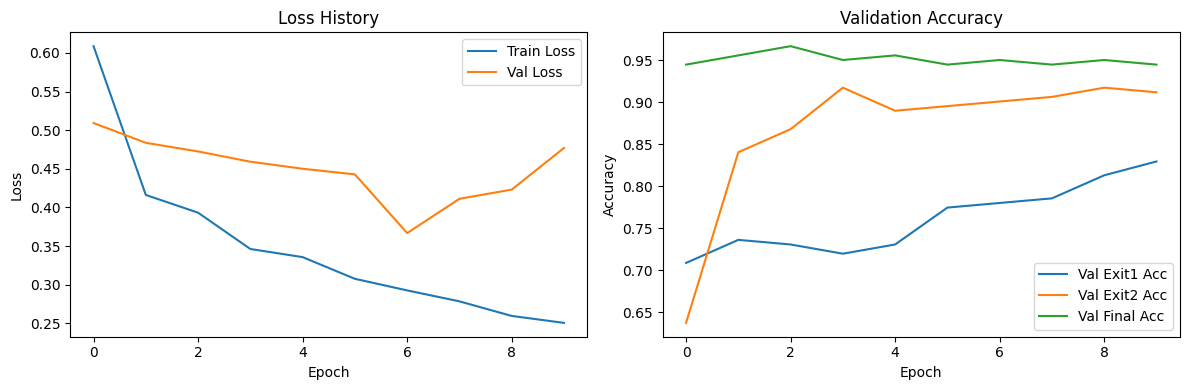

In [52]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss History")

plt.subplot(1, 2, 2)
plt.plot(history["val_exit1_acc"], label="Val Exit1 Acc")
plt.plot(history["val_exit2_acc"], label="Val Exit2 Acc")
plt.plot(history["val_final_acc"], label="Val Final Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation Accuracy")

plt.tight_layout()
plt.show()

### seperating exit evaluation

In [53]:
def evaluate_all_exits(dataloader):
    backbone.eval()
    exit1_head.eval()
    exit2_head.eval()
    final_head.eval()

    correct_exit1 = 0
    correct_exit2 = 0
    correct_final = 0
    total = 0

    all_final_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            exit1_logits, exit2_logits, final_logits = forward_early_exit(inputs)

            pred1 = exit1_logits.argmax(dim=1)
            pred2 = exit2_logits.argmax(dim=1)
            predf = final_logits.argmax(dim=1)

            correct_exit1 += (pred1 == labels).sum().item()
            correct_exit2 += (pred2 == labels).sum().item()
            correct_final += (predf == labels).sum().item()
            total += labels.size(0)

            all_final_preds.extend(predf.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    exit1_acc = correct_exit1 / total
    exit2_acc = correct_exit2 / total
    final_acc = correct_final / total

    print(f"Exit 1 Accuracy: {exit1_acc:.4f}")
    print(f"Exit 2 Accuracy: {exit2_acc:.4f}")
    print(f"Final Exit Accuracy: {final_acc:.4f}")

    return exit1_acc, exit2_acc, final_acc, all_final_preds, all_labels

In [54]:
exit1_acc, exit2_acc, final_acc, val_preds, val_labels = evaluate_all_exits(val_loader)

Exit 1 Accuracy: 0.8297
Exit 2 Accuracy: 0.9121
Final Exit Accuracy: 0.9451


### adding multi exit routing

In [55]:
def evaluate_routed_inference(dataloader, tau1=0.90, tau2=0.90):
    backbone.eval()
    exit1_head.eval()
    exit2_head.eval()
    final_head.eval()

    total = 0
    correct = 0

    exit1_count = 0
    exit2_count = 0
    final_count = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            exit1_logits, exit2_logits, final_logits = forward_early_exit(inputs)

            exit1_probs = torch.softmax(exit1_logits, dim=1)
            exit2_probs = torch.softmax(exit2_logits, dim=1)
            final_probs = torch.softmax(final_logits, dim=1)

            exit1_conf, exit1_pred = exit1_probs.max(dim=1)
            exit2_conf, exit2_pred = exit2_probs.max(dim=1)
            _, final_pred = final_probs.max(dim=1)

            batch_preds = []

            for i in range(labels.size(0)):
                if exit1_conf[i] >= tau1:
                    pred = exit1_pred[i]
                    exit1_count += 1
                elif exit2_conf[i] >= tau2:
                    pred = exit2_pred[i]
                    exit2_count += 1
                else:
                    pred = final_pred[i]
                    final_count += 1

                batch_preds.append(pred.item())

            batch_preds = torch.tensor(batch_preds, device=labels.device)

            correct += (batch_preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(batch_preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = correct / total
    exit1_rate = exit1_count / total
    exit2_rate = exit2_count / total
    final_rate = final_count / total

    print(f"Overall Accuracy: {acc:.4f}")
    print(f"Exit 1 Rate: {exit1_rate:.4f}")
    print(f"Exit 2 Rate: {exit2_rate:.4f}")
    print(f"Final Exit Rate: {final_rate:.4f}")

    return acc, exit1_rate, exit2_rate, final_rate, all_preds, all_labels

In [56]:
routed_acc, exit1_rate, exit2_rate, final_rate, routed_preds, routed_labels = evaluate_routed_inference(val_loader, tau1=0.90, tau2=0.90)

Overall Accuracy: 0.9451
Exit 1 Rate: 0.0000
Exit 2 Rate: 0.2033
Final Exit Rate: 0.7967


### final accuracy with varying exit thresholds

In [57]:
thresholds = [0.70, 0.80, 0.85, 0.90, 0.95]
results = []

for tau in thresholds:
    acc, r1, r2, rf, _, _ = evaluate_routed_inference(val_loader, tau1=tau, tau2=tau)
    results.append((tau, acc, r1, r2, rf))
    print()

Overall Accuracy: 0.9396
Exit 1 Rate: 0.0769
Exit 2 Rate: 0.5549
Final Exit Rate: 0.3681

Overall Accuracy: 0.9451
Exit 1 Rate: 0.0000
Exit 2 Rate: 0.4286
Final Exit Rate: 0.5714

Overall Accuracy: 0.9451
Exit 1 Rate: 0.0000
Exit 2 Rate: 0.3352
Final Exit Rate: 0.6648

Overall Accuracy: 0.9451
Exit 1 Rate: 0.0000
Exit 2 Rate: 0.2033
Final Exit Rate: 0.7967

Overall Accuracy: 0.9451
Exit 1 Rate: 0.0000
Exit 2 Rate: 0.0220
Final Exit Rate: 0.9780



### confusion matrix for final exit

In [58]:
def get_all_exit_predictions(dataloader, tau1=0.90, tau2=0.90):
    backbone.eval()
    exit1_head.eval()
    exit2_head.eval()
    final_head.eval()

    y_true = []
    y_exit1 = []
    y_exit2 = []
    y_final = []
    y_routed = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            exit1_logits, exit2_logits, final_logits = forward_early_exit(inputs)

            exit1_probs = torch.softmax(exit1_logits, dim=1)
            exit2_probs = torch.softmax(exit2_logits, dim=1)

            exit1_conf, exit1_pred = exit1_probs.max(dim=1)
            exit2_conf, exit2_pred = exit2_probs.max(dim=1)
            final_pred = final_logits.argmax(dim=1)

            routed_pred = []
            for i in range(labels.size(0)):
                if exit1_conf[i] >= tau1:
                    pred = exit1_pred[i]
                elif exit2_conf[i] >= tau2:
                    pred = exit2_pred[i]
                else:
                    pred = final_pred[i]
                routed_pred.append(pred.item())

            y_true.extend(labels.cpu().numpy())
            y_exit1.extend(exit1_pred.cpu().numpy())
            y_exit2.extend(exit2_pred.cpu().numpy())
            y_final.extend(final_pred.cpu().numpy())
            y_routed.extend(routed_pred)

    return y_true, y_exit1, y_exit2, y_final, y_routed

In [59]:
y_true, y_exit1, y_exit2, y_final, y_routed = get_all_exit_predictions(
    val_loader, tau1=0.90, tau2=0.90
)

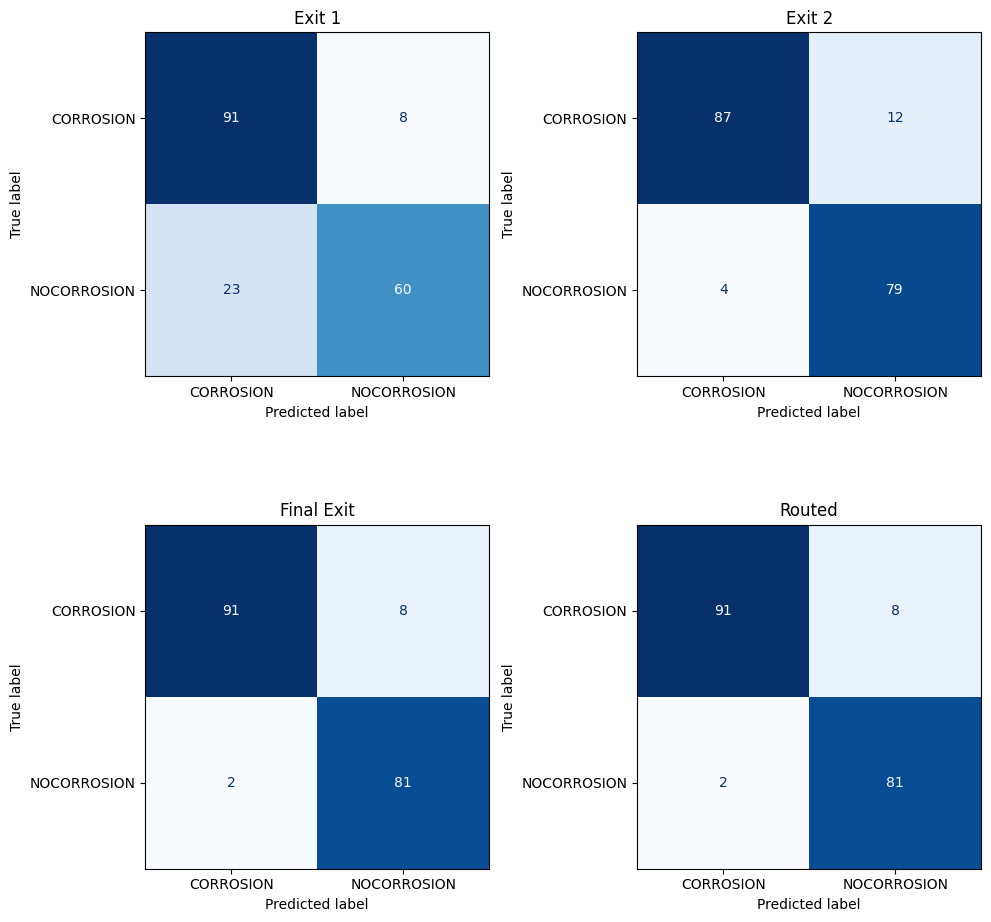

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
pairs = [
("Exit 1", y_exit1, axes[0, 0]),
("Exit 2", y_exit2, axes[0, 1]),
("Final Exit", y_final, axes[1, 0]),
("Routed", y_routed, axes[1, 1])]
for title, preds, ax in pairs:
    cm = confusion_matrix(y_true, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_ds.classes)
    disp.plot(cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(title)

plt.tight_layout()    
plt.show()